In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE = "/content/drive/MyDrive"

train_csv_path = None

for root, dirs, files in os.walk(BASE):
    if "pbc_attr_v1_train.csv" in files:
        train_csv_path = os.path.join(root, "pbc_attr_v1_train.csv")
        break

if train_csv_path is None:
    raise FileNotFoundError(" pbc_attr_v1_train.csv NOT FOUND in MyDrive")

DATA_ROOT = os.path.dirname(train_csv_path)
TRAIN_CSV = train_csv_path
VAL_CSV = os.path.join(DATA_ROOT, "pbc_attr_v1_val.csv")

print(" DATA_ROOT:", DATA_ROOT)
print(" TRAIN_CSV:", TRAIN_CSV)
print(" VAL_CSV:", VAL_CSV)


✅ DATA_ROOT: /content/drive/MyDrive/PCB_DATA
✅ TRAIN_CSV: /content/drive/MyDrive/PCB_DATA/pbc_attr_v1_train.csv
✅ VAL_CSV: /content/drive/MyDrive/PCB_DATA/pbc_attr_v1_val.csv


In [ ]:
IMAGE_ROOT = None

for name in ["DATA", "data", "images", "Images"]:
    candidate = os.path.join(DATA_ROOT, name)
    if os.path.exists(candidate):
        IMAGE_ROOT = candidate
        break

if IMAGE_ROOT is None:
    raise FileNotFoundError("❌ Image folder not found (DATA / data / images)")

print("✅ IMAGE_ROOT:", IMAGE_ROOT)


✅ IMAGE_ROOT: /content/drive/MyDrive/PCB_DATA/DATA


In [ ]:
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets.folder import default_loader

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [ ]:
def make_deterministic(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

make_deterministic(1)


In [ ]:
att_names = [
    "cell_size", "cell_shape", "nucleus_shape",
    "nuclear_cytoplasmic_ratio", "chromatin_density",
    "cytoplasm_vacuole", "cytoplasm_texture",
    "cytoplasm_colour", "granule_type",
    "granule_colour", "granularity"
]


In [ ]:
class AttDataset(Dataset):
    def __init__(self, csv_file, attribute_columns, image_dir,
                 transform=None, attribute_encoders=None, cell_encoder=None):

        self.df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform
        self.attribute_columns = attribute_columns

        if attribute_encoders is None:
            self.attribute_encoders = {
                col: {v: i for i, v in enumerate(sorted(self.df[col].unique()))}
                for col in attribute_columns
            }
        else:
            self.attribute_encoders = attribute_encoders

        if cell_encoder is None:
            self.cell_encoder = {
                v: i for i, v in enumerate(sorted(self.df["label"].unique()))
            }
        else:
            self.cell_encoder = cell_encoder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_rel_path = self.df.loc[idx, "path"]
        img_path = os.path.join(self.image_dir, img_rel_path)

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = default_loader(img_path)

        attrs = [
            self.attribute_encoders[c][self.df.loc[idx, c]]
            for c in self.attribute_columns
        ]

        cell = self.cell_encoder[self.df.loc[idx, "label"]]

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "attributes": torch.tensor(attrs),
            "cell_type": torch.tensor(cell)
        }


In [ ]:
def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize(320),
            transforms.RandomCrop(300),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize(320),
            transforms.CenterCrop(300),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])


In [ ]:
train_ds = AttDataset(
    TRAIN_CSV, att_names, IMAGE_ROOT,
    transform=get_transforms(True)
)

val_ds = AttDataset(
    VAL_CSV, att_names, IMAGE_ROOT,
    transform=get_transforms(False),
    attribute_encoders=train_ds.attribute_encoders,
    cell_encoder=train_ds.cell_encoder
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

print("✅ Train samples:", len(train_ds))
print("✅ Val samples:", len(val_ds))


✅ Train samples: 6169
✅ Val samples: 1030


In [ ]:
def get_encoder():
    model = torchvision.models.efficientnet_b3(weights="DEFAULT")
    feat_dim = model.classifier[1].in_features
    model.classifier[1] = nn.Identity()
    return model, feat_dim

class AttributePredictor(nn.Module):
    def __init__(self, encoder, feat_dim, attr_sizes, num_cells):
        super().__init__()
        self.encoder = encoder
        self.cell_head = nn.Linear(feat_dim, num_cells)
        self.attr_heads = nn.ModuleList(
            [nn.Linear(feat_dim, s) for s in attr_sizes]
        )

    def forward(self, x):
        f = self.encoder(x)
        return self.cell_head(f), [h(f) for h in self.attr_heads]


In [ ]:
num_cell_types = len(train_ds.cell_encoder)
attr_sizes = [len(train_ds.attribute_encoders[a]) for a in att_names]

encoder, feat_dim = get_encoder()

model = AttributePredictor(
    encoder, feat_dim, attr_sizes, num_cell_types
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

print("✅ Model ready")


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 209MB/s]


✅ Model ready


In [ ]:
train_loss_history = []
val_acc_history = []


In [ ]:
num_epochs = 20
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        imgs = batch["image"].to(device)
        attr_targets = batch["attributes"].to(device)
        cell_targets = batch["cell_type"].to(device)

        optimizer.zero_grad()

        cell_logits, attr_outputs = model(imgs)

        loss_cell = criterion(cell_logits, cell_targets)
        loss_attr = sum(
            criterion(out, attr_targets[:, i])
            for i, out in enumerate(attr_outputs)
        ) / len(attr_outputs)

        loss = loss_cell + loss_attr
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # ---------- VALIDATION (CELL TYPE) ----------
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(device)
            targets = batch["cell_type"].to(device)
            logits, _ = model(imgs)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    val_acc = accuracy_score(all_targets, all_preds)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Cell Accuracy: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pth")


Epoch 1/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.2110 | Val Cell Accuracy: 0.9796


Epoch 2/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.3409 | Val Cell Accuracy: 0.9883


Epoch 3/20:   0%|          | 0/193 [00:00<?, ?it/s]

...

Epoch 18 | Train Loss: 0.1425 | Val Cell Accuracy: 0.9961


Epoch 19/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 19 | Train Loss: 0.1381 | Val Cell Accuracy: 0.9942


Epoch 20/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 20 | Train Loss: 0.1332 | Val Cell Accuracy: 0.9961


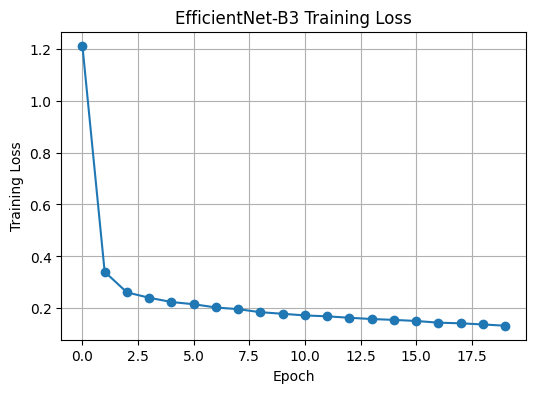

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(train_loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("EfficientNet-B3 Training Loss")
plt.grid(True)
plt.show()


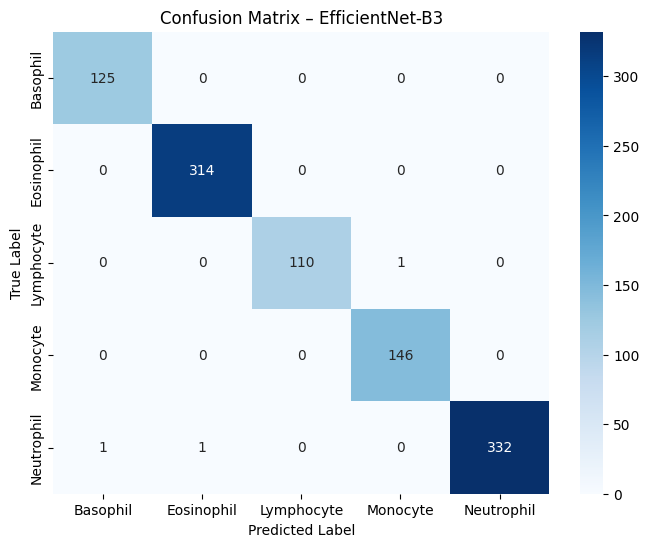

In [ ]:
from sklearn.metrics import confusion_matrix

model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model.pth"))
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for batch in val_loader:
        imgs = batch["image"].to(device)
        targets = batch["cell_type"].to(device)
        logits, _ = model(imgs)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

y_pred = np.array(all_preds)
y_test = np.array(all_targets)

# Decode class names
inv_cell_encoder = {v: k for k, v in train_ds.cell_encoder.items()}
class_names = [inv_cell_encoder[i] for i in range(len(inv_cell_encoder))]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – EfficientNet-B3")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Keep only useful columns
report_df = report_df[["precision", "recall", "f1-score", "support"]]

report_df


,precision,recall,f1-score,support
Basophil,0.992063,1.000000,0.996016,125.000000
Eosinophil,0.996825,1.000000,0.998410,314.000000
Lymphocyte,1.000000,0.990991,0.995475,111.000000
Monocyte,0.993197,1.000000,0.996587,146.000000
Neutrophil,1.000000,0.994012,0.996997,334.000000
accuracy,0.997087,0.997087,0.997087,0.997087
macro avg,0.996417,0.997001,0.996697,1030.000000
weighted avg,0.997105,0.997087,0.997087,1030.000000


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score

def evaluate_attributes(model, loader, att_names, device):
    model.eval()
    probs = [[] for _ in att_names]
    labels = [[] for _ in att_names]

    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            targets = batch["attributes"].to(device)

            _, attr_outputs = model(imgs)

            for i, out in enumerate(attr_outputs):
                p = torch.softmax(out, dim=1).cpu().numpy()
                probs[i].extend(p)
                labels[i].extend(targets[:, i].cpu().numpy())

    rows = []
    for i, name in enumerate(att_names):
        preds = np.argmax(probs[i], axis=1)

        rows.append([
            name,
            accuracy_score(labels[i], preds),
            f1_score(labels[i], preds, average="weighted"),
            precision_score(labels[i], preds, average="weighted")
        ])

    df = pd.DataFrame(
        rows,
        columns=["Attribute", "Accuracy", "F1-Score", "Precision"]
    )

    print("\n=== ATTRIBUTE PERFORMANCE (OVERALL) ===")
    print(df)

    return df

attr_metrics_df = evaluate_attributes(
    model, val_loader, att_names, device
)



=== ATTRIBUTE PERFORMANCE (OVERALL) ===
                    Attribute  Accuracy  F1-Score  Precision
0                   cell_size  0.862136  0.861154   0.864358
1                  cell_shape  0.929126  0.928184   0.927943
2               nucleus_shape  0.736893  0.730974   0.739731
3   nuclear_cytoplasmic_ratio  0.987379  0.987402   0.987429
4           chromatin_density  0.949515  0.952281   0.958069
5           cytoplasm_vacuole  0.962136  0.961575   0.961147
6           cytoplasm_texture  0.959223  0.960113   0.962686
7            cytoplasm_colour  0.920388  0.921631   0.923190
8                granule_type  0.996117  0.996115   0.996117
9              granule_colour  0.990291  0.990224   0.990386
10                granularity  0.999029  0.999030   0.999033


In [ ]:
def evaluate_attributes_per_cell(
    model, loader, att_names, cell_encoder, device
):
    model.eval()
    cell_decoder = {v: k for k, v in cell_encoder.items()}

    data = {
        c: {"probs": [[] for _ in att_names], "labels": [[] for _ in att_names]}
        for c in cell_decoder.keys()
    }

    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            cell_ids = batch["cell_type"].cpu().numpy()
            attr_targets = batch["attributes"].cpu().numpy()

            _, attr_outputs = model(imgs)

            for i, out in enumerate(attr_outputs):
                p = torch.softmax(out, dim=1).cpu().numpy()
                for j, cid in enumerate(cell_ids):
                    data[cid]["probs"][i].append(p[j])
                    data[cid]["labels"][i].append(attr_targets[j, i])

    rows = []
    for cid, cname in cell_decoder.items():
        for i, att in enumerate(att_names):
            if len(data[cid]["labels"][i]) == 0:
                continue

            preds = np.argmax(data[cid]["probs"][i], axis=1)
            labels = data[cid]["labels"][i]

            rows.append([
                cname,
                att,
                accuracy_score(labels, preds),
                f1_score(labels, preds, average="weighted", zero_division=0),
                precision_score(labels, preds, average="weighted", zero_division=0)
            ])

    df = pd.DataFrame(
        rows,
        columns=["Cell Type", "Attribute", "Accuracy", "F1-Score", "Precision"]
    )

    print("\n=== ATTRIBUTE PERFORMANCE PER CELL TYPE ===")
    print(df)

    return df

attr_cell_df = evaluate_attributes_per_cell(
    model,
    val_loader,
    att_names,
    train_ds.cell_encoder,
    device
)



=== ATTRIBUTE PERFORMANCE PER CELL TYPE ===
     Cell Type                  Attribute  Accuracy  F1-Score  Precision
0     Basophil                  cell_size  0.872000  0.875935   0.884419
1     Basophil                 cell_shape  0.904000  0.897473   0.894609
2     Basophil              nucleus_shape  0.488000  0.423062   0.417639
3     Basophil  nuclear_cytoplasmic_ratio  0.992000  0.988016   0.984064
4     Basophil          chromatin_density  1.000000  1.000000   1.000000
5     Basophil          cytoplasm_vacuole  1.000000  1.000000   1.000000
6     Basophil          cytoplasm_texture  1.000000  1.000000   1.000000
7     Basophil           cytoplasm_colour  1.000000  1.000000   1.000000
8     Basophil               granule_type  0.992000  0.988016   0.984064
9     Basophil             granule_colour  1.000000  1.000000   1.000000
10    Basophil                granularity  1.000000  1.000000   1.000000
11  Eosinophil                  cell_size  0.792994  0.785661   0.795801
12  Eo

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/efficientnet_b3_saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)


In [ ]:
num_epochs = 20
save_every = 5

best_val_acc = 0.0
best_epoch = -1
best_model_path = None

train_loss_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        imgs = batch["image"].to(device)
        attr_targets = batch["attributes"].to(device)
        cell_targets = batch["cell_type"].to(device)

        optimizer.zero_grad()

        cell_logits, attr_outputs = model(imgs)

        loss_cell = criterion(cell_logits, cell_targets)
        loss_attr = sum(
            criterion(out, attr_targets[:, i])
            for i, out in enumerate(attr_outputs)
        ) / len(attr_outputs)

        loss = loss_cell + loss_attr
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # ---------- VALIDATION ----------
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(device)
            targets = batch["cell_type"].to(device)

            logits, _ = model(imgs)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    val_acc = accuracy_score(all_targets, all_preds)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Accuracy: {val_acc:.4f}"
    )

    # -------- SAVE EVERY N EPOCHS --------
    if (epoch + 1) % save_every == 0:
        save_path = f"{SAVE_DIR}/efficientnet_b3_epoch_{epoch+1}.pth"
        torch.save({
            "epoch": epoch + 1,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_accuracy": val_acc
        }, save_path)
        print(f"✔ Saved checkpoint: {save_path}")

    # -------- SAVE BEST MODEL --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_path = f"{SAVE_DIR}/best_model.pth"

        torch.save({
            "epoch": best_epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_accuracy": best_val_acc
        }, best_model_path)

print("\n==============================")
print(f"✅ BEST MODEL EPOCH: {best_epoch}")
print(f"✅ BEST VAL ACCURACY: {best_val_acc:.4f}")
print(f"📁 BEST MODEL PATH: {best_model_path}")
print("==============================\n")


Epoch 1/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.0671 | Val Accuracy: 0.9981


Epoch 2/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.0640 | Val Accuracy: 0.9981


Epoch 3/20:   0%|          | 0/193 [00:00<?, ?it/s]

...

Epoch 5/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 5 | Train Loss: 0.0557 | Val Accuracy: 0.9971
✔ Saved checkpoint: /content/drive/MyDrive/efficientnet_b3_saved_models/efficientnet_b3_epoch_5.pth


Epoch 6/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 6 | Train Loss: 0.0548 | Val Accuracy: 0.9971


Epoch 7/20:   0%|          | 0/193 [00:00<?, ?it/s]